# Notebook 10 — Visualizing the submissions

A look at what our forecasts actually *look like*, day by day. The test period (16–31 August 2017) has no public ground truth, so we plot the **predicted daily totals** of each submission, anchored to the **actual** sales of the days leading up to the forecast. Submissions are labelled with their public RMSLE so the visual differences can be tied to score differences.

> 🇷🇺 Смотрим, как выглядят наши прогнозы по дням. У тестового периода (16–31 августа 2017) нет публичного факта, поэтому рисуем **предсказанные суммарные продажи по дням** для каждого сабмишна, пристыкованные к **реальным** продажам предшествующих дней. В подписях — публичный RMSLE, чтобы связать визуальные различия со скором.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
DATA = "../data"
test = pd.read_csv(os.path.join(DATA, "test.csv"), parse_dates=["date"])
train = pd.read_parquet("../artifacts/train_preprocessed.parquet")

# Curated submissions with their public leaderboard scores (worst -> best)
# Отобранные сабмишны с их публичными скорами (от худшего к лучшему)
SUBS = [
    ("direct blend (exp 08)",   "../submission_08_direct_blend20.csv",     0.39417),
    ("model_2016",              "../submission_03_model_2016.csv",                 0.39320),
    ("hybrid (exp 04)",         "../submission_04_hybrid.csv",                    0.39243),
    ("model_2017 (original)",   "../submission_03_model_2017.csv",           0.39109),
    ("geo_blend25 (exp 05)",    "../submission_05_geo_blend25.csv",        0.38899),
    ("best mix",                "../submission_mix_geo_blend25.csv",   0.38803),
]
SUBS = [(lbl, p, sc) for lbl, p, sc in SUBS if os.path.exists(p)]

# Map each submission's id -> (date, store, family); keep a daily-total series
# Сопоставляем id -> (дата, магазин, категория); считаем суммарные продажи по дням
key = test[["id", "date", "store_nbr", "family"]]
daily = {}
longsub = {}
for lbl, path, sc in SUBS:
    s = pd.read_csv(path).merge(key, on="id")
    longsub[lbl] = s
    daily[lbl] = s.groupby("date")["sales"].sum()

actual_daily = train.groupby("date")["sales"].sum()
print(f"{len(SUBS)} submissions | test days: {test['date'].nunique()} "
      f"({test['date'].min().date()} .. {test['date'].max().date()})")

6 submissions | test days: 16 (2017-08-16 .. 2017-08-31)


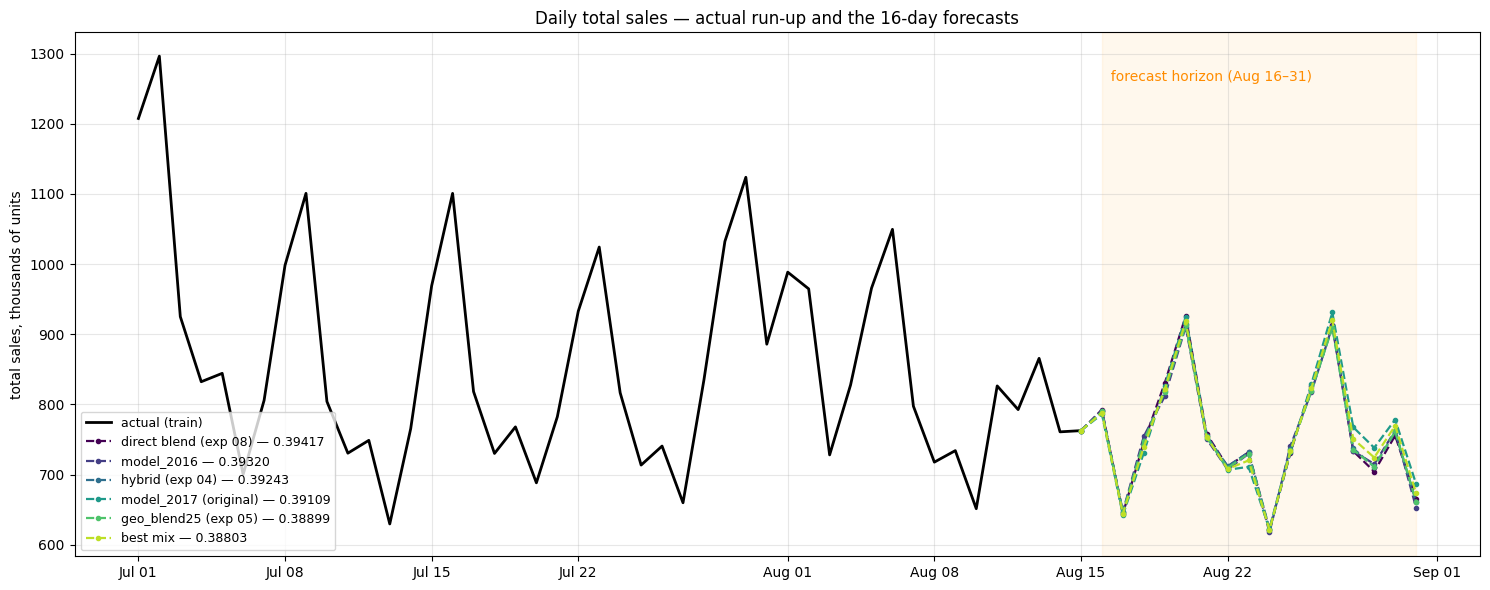

In [3]:
# Plot 1 — forecasts in context: actual run-up + each submission's 16-day forecast
# График 1 — прогнозы в контексте: реальный «разбег» + 16-дневный прогноз каждого сабмишна
ctx_start = pd.Timestamp("2017-07-01")
fc_start = pd.Timestamp("2017-08-16")
act = actual_daily[actual_daily.index >= ctx_start]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(act.index, act.values / 1e3, color="black", lw=2, label="actual (train)")
# bridge the gap: connect last actual to first forecast for each submission
last_day = act.index.max(); last_val = act.loc[last_day]
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(SUBS)))
for (lbl, _, sc), c in zip(SUBS, cmap):
    d = daily[lbl]
    xs = [last_day] + list(d.index); ys = [last_val] + list(d.values)
    ax.plot(xs, np.array(ys) / 1e3, "--", color=c, lw=1.6, marker="o", ms=3,
            label=f"{lbl} — {sc:.5f}")
ax.axvspan(fc_start, test["date"].max(), color="orange", alpha=0.07)
ax.text(fc_start, ax.get_ylim()[1]*0.96, "  forecast horizon (Aug 16–31)", color="darkorange", va="top")
ax.set_title("Daily total sales — actual run-up and the 16-day forecasts")
ax.set_ylabel("total sales, thousands of units"); ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d")); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

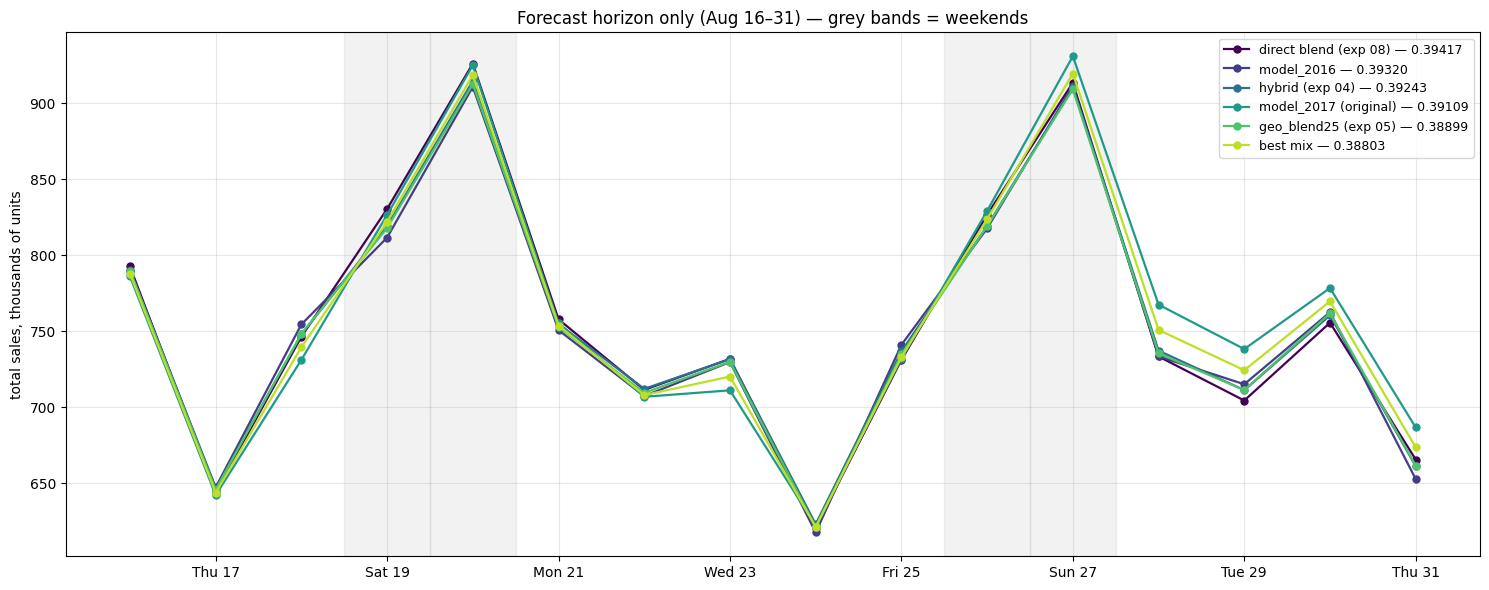

Note: all submissions share the weekly rhythm (weekend dips); they differ mostly in level.
The lower-scoring 'best mix' sits between the recency-rich model_2017 and the geo blend.


In [4]:
# Plot 2 — zoom on the forecast horizon: compare the submissions' daily shapes
# График 2 — увеличение на горизонте прогноза: сравниваем форму по дням
fig, ax = plt.subplots(figsize=(15, 6))
for (lbl, _, sc), c in zip(SUBS, cmap):
    d = daily[lbl]
    ax.plot(d.index, d.values / 1e3, marker="o", ms=5, lw=1.6, color=c, label=f"{lbl} — {sc:.5f}")
# shade weekends
for dt in pd.date_range(fc_start, test["date"].max()):
    if dt.dayofweek >= 5:
        ax.axvspan(dt - pd.Timedelta(hours=12), dt + pd.Timedelta(hours=12), color="grey", alpha=0.10)
ax.set_title("Forecast horizon only (Aug 16–31) — grey bands = weekends")
ax.set_ylabel("total sales, thousands of units"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d")); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Note: all submissions share the weekly rhythm (weekend dips); they differ mostly in level.")
print("The lower-scoring 'best mix' sits between the recency-rich model_2017 and the geo blend.")

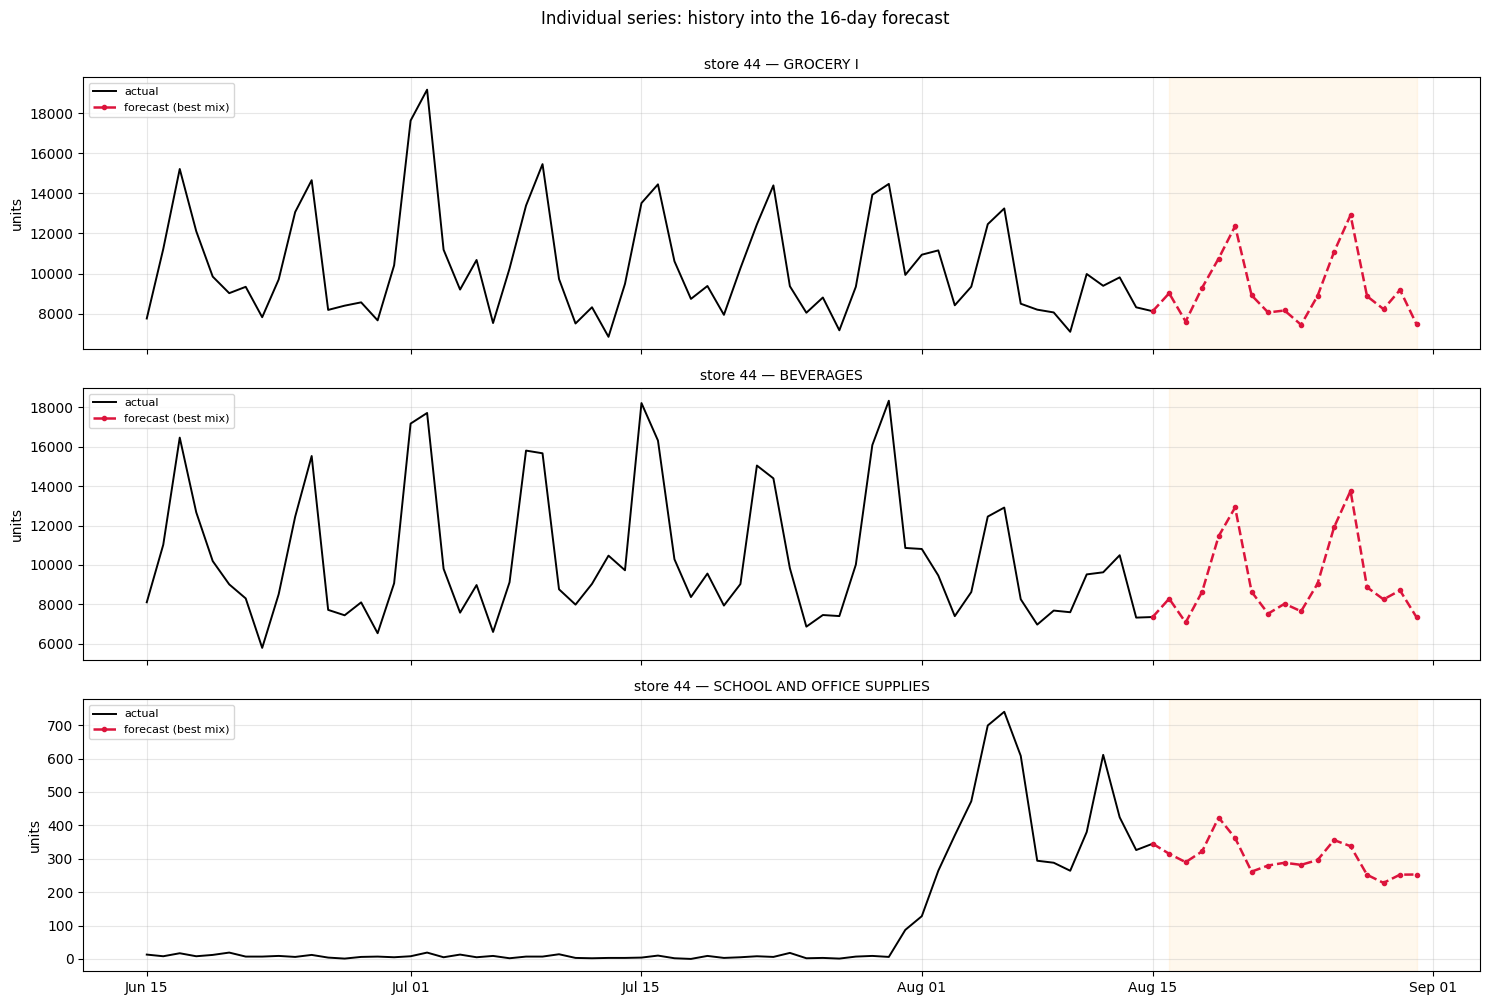

GROCERY I / BEVERAGES: stable weekly seasonality, forecast continues the level.
SCHOOL AND OFFICE SUPPLIES: the back-to-school August ramp the model has to capture.


In [5]:
# Plot 3 — a few individual series: actual history + best-mix forecast
# График 3 — отдельные ряды: реальная история + прогноз лучшего микса
best_lbl = SUBS[-1][0]
best = longsub[best_lbl]
examples = [(44, "GROCERY I"), (44, "BEVERAGES"), (44, "SCHOOL AND OFFICE SUPPLIES")]
hist_start = pd.Timestamp("2017-06-15")

fig, axes = plt.subplots(len(examples), 1, figsize=(15, 10), sharex=True)
for ax, (st, fam) in zip(axes, examples):
    h = train[(train.store_nbr == st) & (train.family == fam) & (train.date >= hist_start)]
    f = best[(best.store_nbr == st) & (best.family == fam)].sort_values("date")
    ax.plot(h["date"], h["sales"], color="black", lw=1.4, label="actual")
    bridge_x = [h["date"].max()] + list(f["date"]); bridge_y = [h["sales"].iloc[-1]] + list(f["sales"])
    ax.plot(bridge_x, bridge_y, "--", color="crimson", lw=1.8, marker="o", ms=3, label=f"forecast ({best_lbl})")
    ax.axvspan(fc_start, test["date"].max(), color="orange", alpha=0.07)
    ax.set_title(f"store {st} — {fam}", fontsize=10); ax.set_ylabel("units"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.suptitle("Individual series: history into the 16-day forecast", y=1.0)
plt.tight_layout(); plt.show()

print("GROCERY I / BEVERAGES: stable weekly seasonality, forecast continues the level.")
print("SCHOOL AND OFFICE SUPPLIES: the back-to-school August ramp the model has to capture.")

## What the pictures show

- **All submissions share the same weekly rhythm** — the day-of-week seasonality (weekend dips) is the dominant signal, and every model captures it well. The submissions differ mainly in **level**, not shape.
- The score differences (0.394 → 0.388) come from small, consistent level corrections across 28,512 cells, not from a visibly "better" curve — which is why the gap to the leaderboard is hard to close and why sub-0.003 validation moves get lost in the noise.
- At the **individual-series** level the forecast cleanly continues each series' weekly pattern and level; the interesting cases are the seasonal ramps (school supplies in August), where getting the slope right matters most.

## Что видно на графиках

- **Все сабмишны разделяют один недельный ритм** — главный сигнал это недельная сезонность (провалы на выходных), и его хорошо ловят все модели. Различаются сабмишны в основном **уровнем**, а не формой.
- Разница в скоре (0.394 → 0.388) — это мелкие согласованные поправки уровня по 28 512 клеткам, а не визуально «более красивая» кривая. Поэтому разрыв с лидербордом так трудно закрыть, а под-шумовые движения валидации (меньше 0.003) теряются.
- На уровне **отдельных рядов** прогноз аккуратно продолжает недельный профиль и уровень каждого ряда; интереснее всего сезонные разгоны (школьные товары в августе), где важнее всего угадать наклон.